# 🧬 Meme Kanseri Sınıflandırması — PCA ile Boyut İndirgeme

**🇹🇷 Türkçe:**
Bu notebook, klasik **Breast Cancer Wisconsin** veri setinde (569 örnek, 30 sayısal özellik, iyi huylu/kötü huylu ikili hedef) **PCA (Principal Component Analysis)**'nin boyut indirgeme etkisini inceliyor. `LogisticRegression` ve `GradientBoostingClassifier`, önce tüm 30 özellikle, sonra PCA ile 30'dan 4 bileşene indirgenmiş veriyle eğitiliyor — boyut indirgemenin doğruluğa maliyeti ne kadar?

Son bölümde, veri sadece görselleştirme amacıyla 2 temel bileşene indirgenip iki sınıfın (iyi huylu/kötü huylu) 2 boyutlu uzayda ne kadar ayrılabildiği gösteriliyor.

**🇬🇧 English:**
This notebook examines what **PCA (Principal Component Analysis)** costs and buys on the classic **Breast Cancer Wisconsin** dataset (569 samples, 30 numeric features, a binary benign/malignant target). `LogisticRegression` and `GradientBoostingClassifier` are trained first on all 30 features, then on data reduced from 30 to 4 components via PCA — how much accuracy does dimensionality reduction cost?

In the final section, the data is reduced to just 2 principal components purely for visualization, showing how well the two classes (benign/malignant) separate in 2D.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme ve görselleştirme kütüphaneleri yükleniyor.

**⚠️ Dürüst bir not — kırılgan bir satır:** Bu hücrede daha önce `from jupyterlab.extensions.pypi import xmlrpc_transport_override` satırı vardı — muhtemelen IDE'nin otomatik tamamlamasından kazara eklenmiş, notebook'un geri kalanında hiç kullanılmayan bir import. Yerel ortamda hata vermiyordu (modül orada gerçekten var, sadece `None` değerinde bir öznitelik), ama bu bir tesadüftü: Kaggle'da kernel çalıştırıldığında `ModuleNotFoundError: No module named 'jupyterlab.extensions'` ile **çöktü**. Satır kaldırıldı — bu, "hata vermiyor" ile "taşınabilir/güvenilir" ifadelerinin aynı şey olmadığının somut bir örneği.

**🇬🇧 English:**
Libraries for data handling and visualization are loaded.

**⚠️ An honest note — a fragile line:** This cell previously had `from jupyterlab.extensions.pypi import xmlrpc_transport_override` — most likely pulled in by accident from IDE autocomplete, never used anywhere else in the notebook. It didn't error locally (the module genuinely exists there, just an attribute that happens to be `None`), but that was a coincidence: running the kernel on Kaggle **crashed** with `ModuleNotFoundError: No module named 'jupyterlab.extensions'`. The line has been removed — a concrete example that "doesn't error" and "portable/reliable" aren't the same thing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
`sklearn.datasets.load_breast_cancer(as_frame=True)` ile klasik meme kanseri veri seti bir DataFrame olarak yükleniyor: 569 örnek, 30 sayısal özellik (hücre çekirdeği ölçümlerinin `mean`/`error`/`worst` istatistikleri) ve ikili `target` kolonu (0 = kötü huylu, 1 = iyi huylu). (Bir sonraki hücredeki ikinci `import` satırı zararsız bir tekrar.)

**🇬🇧 English:**
The classic breast cancer dataset is loaded as a DataFrame via `sklearn.datasets.load_breast_cancer(as_frame=True)`: 569 samples, 30 numeric features (`mean`/`error`/`worst` statistics of cell-nucleus measurements), and a binary `target` column (0 = malignant, 1 = benign). (The second `import` line in the next cell is a harmless repeat.)

In [4]:
from sklearn.datasets import load_breast_cancer

In [5]:
data = load_breast_cancer(as_frame=True)
df = data.frame

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`info()`, `describe()`, `head()`, `isnull().sum()` ve `duplicated().sum()` ile veri sağlığı kontrol ediliyor: **eksik değer yok, tekrar eden satır yok** — bu, PCA gibi ölçeğe duyarlı bir teknik için temiz bir başlangıç noktası.

**🇬🇧 English:**
`info()`, `describe()`, `head()`, `isnull().sum()`, and `duplicated().sum()` check the data's health: **no missing values, no duplicate rows** — a clean starting point for a scale-sensitive technique like PCA.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [8]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## ✂️ 3. Train/Test Ayrımı ve Ölçekleme / Train/Test Split & Scaling

**🇹🇷 Türkçe:**
Veri %75 eğitim / %25 test olarak bölünüyor. `StandardScaler`, **sadece eğitim setinde** `fit` ediliyor ve her iki sete de uygulanıyor. Ölçekleme, PCA için özellikle kritik: PCA en yüksek varyanslı yönleri arıyor, ve ölçeklenmemiş özelliklerde (örneğin `mean area`'nın binlerce, `mean smoothness`'ın 0.1 civarında değerler alması gibi) sonuç sadece birimi büyük olan kolonlara göre şekillenirdi.

**🇬🇧 English:**
The data is split 75% train / 25% test. `StandardScaler` is fit **only on the training set** and applied to both. Scaling matters especially for PCA: PCA looks for the highest-variance directions, and on unscaled features (e.g. `mean area` in the thousands vs. `mean smoothness` around 0.1) the result would simply be dictated by whichever columns happen to have larger units.

In [11]:
X = df.drop('target', axis=1)
y = df['target']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
columns = data.feature_names

In [18]:
X_test = pd.DataFrame(X_test, columns = columns)
X_train = pd.DataFrame(X_train, columns = columns)

## 🚀 4. Temel Modeller — Tüm 30 Özellik / Baseline Models — All 30 Features

**🇹🇷 Türkçe:**
`LogisticRegression` ve `GradientBoostingClassifier`, ölçeklenmiş 30 özelliğin tamamıyla eğitiliyor. Sonuçlar: Logistic Regression **%95,8 doğruluk**, Gradient Boosting **%95,1 doğruluk** — ikisi de PCA öncesi kıyaslama noktası (baseline) olarak kullanılıyor.

**🇬🇧 English:**
`LogisticRegression` and `GradientBoostingClassifier` are trained on all 30 scaled features. Results: Logistic Regression reaches **95.8% accuracy**, Gradient Boosting **95.1% accuracy** — both serve as the pre-PCA baseline.

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [20]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

In [21]:
logistic.fit(X_train, y_train)
gbc.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
y_pred_logistic = logistic.predict(X_test)
print(confusion_matrix(y_test, y_pred_logistic))
print(classification_report(y_test, y_pred_logistic))
print(accuracy_score(y_test, y_pred_logistic))
y_pred_gbc = gbc.predict(X_test)
print(confusion_matrix(y_test, y_pred_gbc))
print(classification_report(y_test, y_pred_gbc))
print(accuracy_score(y_test, y_pred_gbc))

[[49  4]
 [ 2 88]]
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

0.958041958041958
[[47  6]
 [ 1 89]]
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        53
           1       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143

0.951048951048951


## 🧬 5. PCA ile Boyut İndirgeme (4 Bileşen) / Dimensionality Reduction with PCA (4 Components)

**🇹🇷 Türkçe:**
`PCA(n_components=4)`, **sadece ölçeklenmiş `X_train`** üzerinde `fit` ediliyor, sonra hem eğitim hem test verisi 4 temel bileşene dönüştürülüyor (`PCA1`–`PCA4`) — 30 özellik 4'e iniyor. Aynı iki model bu 4 bileşenle yeniden eğitiliyor. Sonuç: Logistic Regression **%93,7**, Gradient Boosting **%91,6** — her ikisi de baseline'ın biraz altında (sırasıyla -2,1 ve -3,5 puan). Bu beklenen bir maliyet: 4 bileşen, orijinal 30 özelliğin varyansının tamamını değil, sadece bir kısmını taşıyor; karşılığında model 30 yerine 4 girdiyle çalışıyor.

**🇬🇧 English:**
`PCA(n_components=4)` is fit **only on the scaled `X_train`**, then both train and test data are transformed into 4 principal components (`PCA1`–`PCA4`) — 30 features become 4. The same two models are retrained on these 4 components. Result: Logistic Regression **93.7%**, Gradient Boosting **91.6%** — both slightly below baseline (-2.1 and -3.5 points respectively). This is an expected cost: 4 components carry only part of the original 30 features' variance, not all of it; in exchange, the model works with 4 inputs instead of 30.

In [24]:
from sklearn.decomposition import PCA

In [36]:
pca = PCA(n_components=4)

In [37]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [38]:
X_train_pca = pd.DataFrame(X_train_pca, columns = ["PCA1", "PCA2", "PCA3", "PCA4"])
X_test_pca = pd.DataFrame(X_test_pca, columns = ["PCA1", "PCA2","PCA3", "PCA4"])

In [39]:
X_train_pca.head()

,PCA1,PCA2,PCA3,PCA4
0,-0.478413,-0.480238,-0.905738,-1.388936
1,-3.476482,-2.219422,0.405915,-1.473204
2,-3.054738,-2.309091,-0.288076,-0.074841
3,1.628649,2.254628,-3.204102,-0.170868
4,1.231041,-1.899407,0.541593,2.300880


In [40]:
logistic_pca = LogisticRegression()
gbc_pca = GradientBoostingClassifier()

In [41]:
logistic_pca.fit(X_train_pca, y_train)
gbc_pca.fit(X_train_pca, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [42]:
y_pred_logistic = logistic_pca.predict(X_test_pca)
print(confusion_matrix(y_test, y_pred_logistic))
print(classification_report(y_test, y_pred_logistic))
print(accuracy_score(y_test, y_pred_logistic))
y_pred_gbc = gbc_pca.predict(X_test_pca)
print(confusion_matrix(y_test, y_pred_gbc))
print(classification_report(y_test, y_pred_gbc))
print(accuracy_score(y_test, y_pred_gbc))

[[48  5]
 [ 4 86]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        53
           1       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143

0.9370629370629371
[[48  5]
 [ 7 83]]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        53
           1       0.94      0.92      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143

0.916083916083916


## 📊 6. 2 Boyutlu Görselleştirme / 2D Visualization

**🇹🇷 Türkçe:**
Son olarak, tüm veri seti (`df`, train/test ayrımı olmadan) ölçeklenip 2 temel bileşene indirgeniyor ve `target`'a göre renklendirilmiş bir saçılım grafiğinde çiziliyor. Burada train/test ayrımı yapılmadan tüm verinin kullanılması bir sızıntı (leakage) değil — çünkü amaç bir modeli test setinde değerlendirmek değil, sadece iki sınıfın 2 boyutlu uzayda ne kadar ayrılabildiğini görsel olarak incelemek.

**🇬🇧 English:**
Finally, the entire dataset (`df`, no train/test split) is scaled and reduced to 2 principal components, then plotted on a scatter plot colored by `target`. Using the full dataset without a train/test split here is not leakage — the goal isn't to evaluate a model on a test set, just to visually inspect how well the two classes separate in 2D.

In [43]:
X = df.drop('target', axis=1)

In [44]:
scaler = StandardScaler()

In [45]:
X = scaler.fit_transform(X)

In [46]:
pca = PCA(n_components=2)

In [47]:
X = pca.fit_transform(X)

In [48]:
X = pd.DataFrame(X, columns = ["PCA1", "PCA2"])

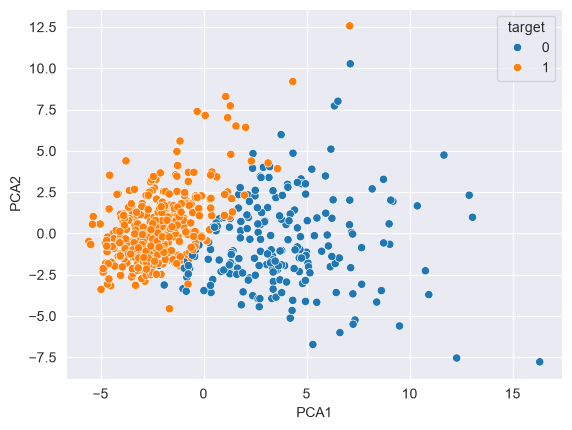

In [53]:
sns.scatterplot(X , x = "PCA1", y = "PCA2", hue=df["target"])
plt.show()